# Corpus v1 — descriptive overview

Reads `data/v1/papers.duckdb` (a view layer over `data/v1/parquet/<journal_slug>/<year>.parquet`).
Re-execute after a smoke run or after the overnight harvest:
```bash
uv run jupyter execute notebooks/01_corpus_overview.ipynb
```

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Locate the corpus DuckDB by walking up from cwd (notebook may run from
# notebooks/ via `jupyter execute` or from repo root via `nbconvert`).
_probe = Path.cwd()
DUCKDB_PATH = None
for _ in range(5):
    candidate = _probe / "data" / "v1" / "papers.duckdb"
    if candidate.exists():
        DUCKDB_PATH = candidate
        break
    _probe = _probe.parent
assert (
    DUCKDB_PATH is not None
), "missing data/v1/papers.duckdb; run `uv run scifield harvest` first."

con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
con.execute("SELECT 1").fetchone()

(1,)

In [2]:
total = con.execute("SELECT COUNT(*) FROM papers").fetchone()[0]
print(f"total papers: {total:,}")

journals_df = con.execute(
    "SELECT journal_slug, journal, journal_ta, COUNT(*) AS n_papers "
    "FROM papers GROUP BY 1, 2, 3 ORDER BY n_papers DESC"
).fetch_df()
journals_df

total papers: 134,978


,journal_slug,journal,journal_ta,n_papers
0,j_arthroplasty,The Journal of arthroplasty,J Arthroplasty,17298
1,clin_orthop_relat_res,Clinical orthopaedics and related research,Clin Orthop Relat Res,16954
2,spine,Spine,Spine (Phila Pa 1976),16865
3,surgery,Surgery,Surgery,15355
4,ann_surg,Annals of surgery,Ann Surg,12980
5,j_bone_joint_surg_am,The Journal of bone and joint surgery. America...,J Bone Joint Surg Am,12662
6,arthroscopy,Arthroscopy : the journal of arthroscopic & re...,Arthroscopy,11863
7,br_j_surg,The British journal of surgery,Br J Surg,11583
8,j_am_coll_surg,Journal of the American College of Surgeons,J Am Coll Surg,10232
9,jama_surg,JAMA surgery,JAMA Surg,4766


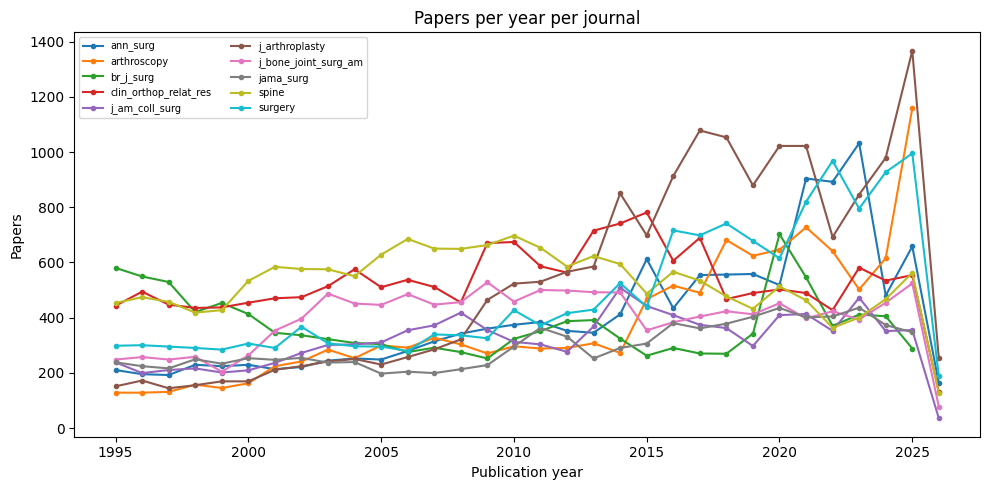

In [3]:
trend = con.execute(
    "SELECT journal_slug, year, COUNT(*) AS n "
    "FROM papers WHERE year IS NOT NULL "
    "GROUP BY journal_slug, year ORDER BY journal_slug, year"
).fetch_df()

fig, ax = plt.subplots(figsize=(10, 5))
for slug, grp in trend.groupby("journal_slug"):
    ax.plot(grp["year"], grp["n"], marker="o", markersize=3, label=slug)
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers")
ax.set_title("Papers per year per journal")
ax.legend(loc="best", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

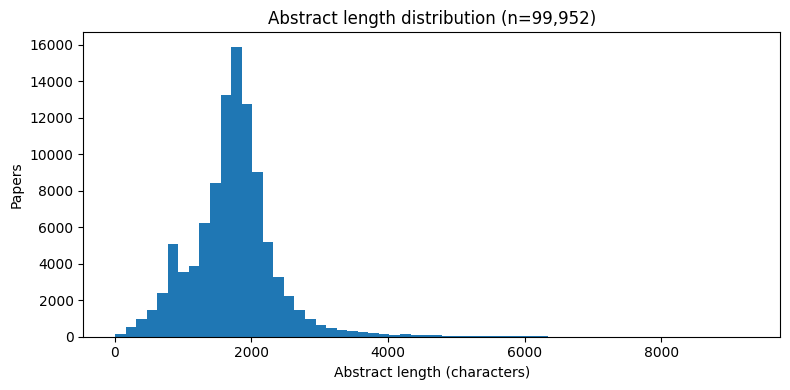

In [4]:
abs_lens = con.execute("SELECT LENGTH(abstract) AS chars FROM papers WHERE has_abstract").fetch_df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(abs_lens["chars"], bins=60)
ax.set_xlabel("Abstract length (characters)")
ax.set_ylabel("Papers")
ax.set_title(f"Abstract length distribution (n={len(abs_lens):,})")
fig.tight_layout()
plt.show()

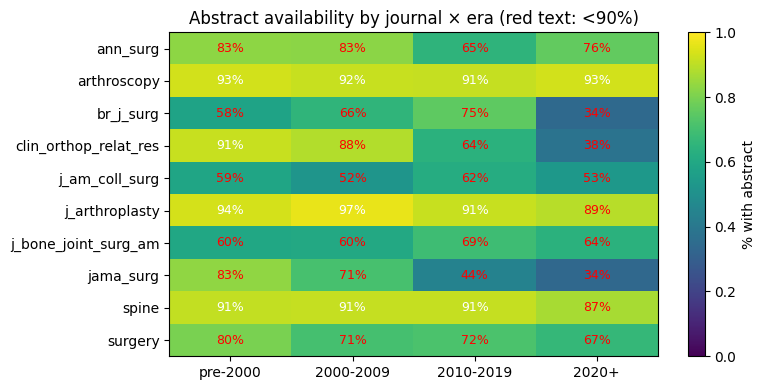

In [5]:
era_q = """
SELECT
  journal_slug,
  CASE
    WHEN year < 2000 THEN 'pre-2000'
    WHEN year BETWEEN 2000 AND 2009 THEN '2000-2009'
    WHEN year BETWEEN 2010 AND 2019 THEN '2010-2019'
    WHEN year >= 2020 THEN '2020+'
    ELSE 'unknown'
  END AS era,
  AVG(CASE WHEN has_abstract THEN 1.0 ELSE 0.0 END) AS pct_with_abstract
FROM papers
GROUP BY 1, 2
"""
era = con.execute(era_q).fetch_df()
era_pivot = era.pivot(index="journal_slug", columns="era", values="pct_with_abstract")
era_pivot = era_pivot.reindex(columns=["pre-2000", "2000-2009", "2010-2019", "2020+"])

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(era_pivot))))
im = ax.imshow(era_pivot.values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
ax.set_xticks(range(era_pivot.shape[1]))
ax.set_xticklabels(era_pivot.columns)
ax.set_yticks(range(era_pivot.shape[0]))
ax.set_yticklabels(era_pivot.index)
for i in range(era_pivot.shape[0]):
    for j in range(era_pivot.shape[1]):
        v = era_pivot.values[i, j]
        if pd.isna(v):
            continue
        color = "red" if v < 0.90 else "white"
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", color=color, fontsize=9)
plt.colorbar(im, ax=ax, label="% with abstract")
ax.set_title("Abstract availability by journal × era (red text: <90%)")
fig.tight_layout()
plt.show()

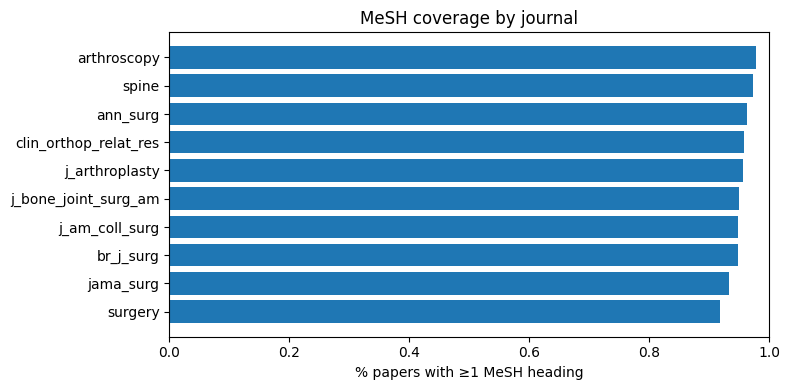

In [6]:
mesh_q = """
SELECT journal_slug,
  AVG(CASE WHEN LENGTH(mesh_headings) > 0 THEN 1.0 ELSE 0.0 END) AS pct_with_mesh
FROM papers
GROUP BY 1
ORDER BY pct_with_mesh DESC
"""
mesh_df = con.execute(mesh_q).fetch_df()

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(mesh_df))))
ax.barh(mesh_df["journal_slug"], mesh_df["pct_with_mesh"])
ax.set_xlim(0, 1)
ax.set_xlabel("% papers with ≥1 MeSH heading")
ax.set_title("MeSH coverage by journal")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

In [7]:
pre2000 = con.execute(
    "SELECT AVG(CASE WHEN has_abstract THEN 1.0 ELSE 0.0 END) AS pct "
    "FROM papers WHERE year < 2000"
).fetchone()[0]
n_pre2000 = con.execute("SELECT COUNT(*) FROM papers WHERE year < 2000").fetchone()[0]
if pre2000 is None or n_pre2000 == 0:
    print("Pre-2000 abstract availability: no pre-2000 papers in this corpus slice.")
else:
    print(f"Pre-2000 abstract availability: {pre2000:.1%} of {n_pre2000:,} papers")
    print("Append this number to docs/phases/1_corpus.md (manual, not auto-generated).")
con.close()

Pre-2000 abstract availability: 78.2% of 14,452 papers
Append this number to docs/phases/1_corpus.md (manual, not auto-generated).
